# Phase 2 – Baseline Modell: Poisson-Regression

**Ziel:** Poisson-GLM als Baseline trainieren und MAE, RMSE, R² dokumentieren.

**Voraussetzung:** `models/features_aggregated.pkl` aus Phase 1 muss existieren.

In [1]:
import sys
import warnings
from pathlib import Path
from math import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import FEATURE_COLUMNS

print('Imports OK')

Imports OK


## 2.1 – Daten laden

In [2]:
import joblib

PKL_PATH = ROOT / 'models' / 'features_aggregated.pkl'
df = joblib.load(PKL_PATH)
print(f'Geladen: {PKL_PATH}')
print(f'Shape: {df.shape}')

TARGET = 'einsatz_count'
X = df[FEATURE_COLUMNS]
y = df[TARGET]

print(f'\nFeatures: {FEATURE_COLUMNS}')
print(f'Zielvariable: {TARGET} – min={y.min()}, max={y.max()}, mean={y.mean():.2f}')

Geladen: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\models\features_aggregated.pkl
Shape: (33437, 9)

Features: ['gebiet_id', 'hour', 'weekday', 'month', 'quarter', 'is_weekend', 'season']
Zielvariable: einsatz_count – min=1, max=5, mean=1.14


## 2.2 – Train/Test-Split

In [3]:
# 80/20 Split; random_state=42 für Reproduzierbarkeit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (26749, 7)  |  Test: (6688, 7)


## 2.3 – Poisson-Regression (GLM)

In [4]:
# Konstante hinzufügen (statsmodels fügt sie nicht automatisch hinzu)
X_train_sm = sm.add_constant(X_train, has_constant='add')
X_test_sm  = sm.add_constant(X_test,  has_constant='add')

# GLM mit Poisson-Familie fitten
glm = sm.GLM(y_train, X_train_sm, family=sm.families.Poisson())
result = glm.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          einsatz_count   No. Observations:                26749
Model:                            GLM   Df Residuals:                    26741
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -29265.
Date:                Tue, 30 Jun 2026   Deviance:                       2832.1
Time:                        23:39:09   Pearson chi2:                 3.59e+03
No. Iterations:                     4   Pseudo R-squ. (CS):          0.0003791
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1471      0.025      5.945      0.0

## 2.4 – Metriken berechnen

In [5]:
y_pred = result.predict(X_test_sm)

mae  = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('\n--- Poisson Baseline Metriken ---')
print(f'  MAE  = {mae:.4f}')
print(f'  RMSE = {rmse:.4f}')
print(f'  R²   = {r2:.4f}')

# Für Vergleich in Phase 3 merken
baseline_metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
joblib.dump(baseline_metrics, ROOT / 'models' / 'baseline_metrics.pkl')
print('\nMetriken als baseline_metrics.pkl gespeichert.')


--- Poisson Baseline Metriken ---
  MAE  = 0.2396
  RMSE = 0.3828
  R²   = 0.0021

Metriken als baseline_metrics.pkl gespeichert.


## 2.5 – Residuenplot: Predicted vs. Actual

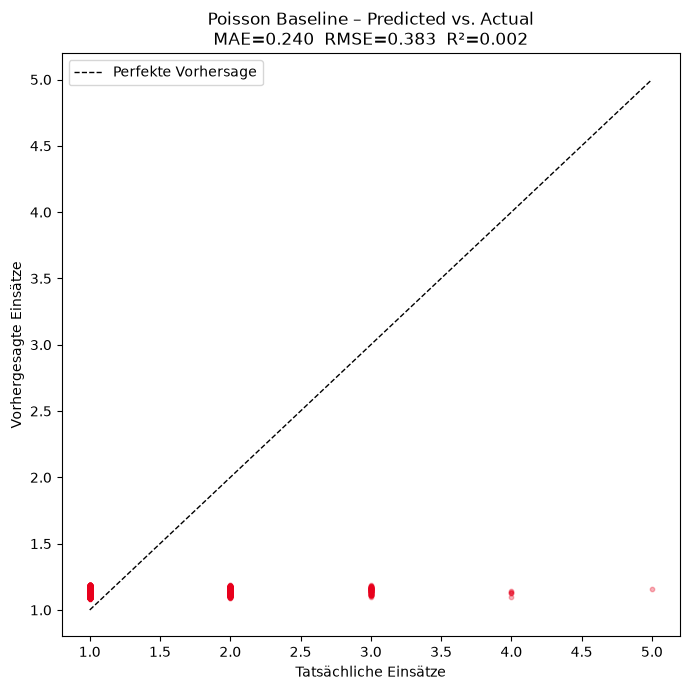

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\baseline_residuen.png


In [6]:
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='#E8001C')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', lw=1, label='Perfekte Vorhersage')
ax.set_xlabel('Tatsächliche Einsätze')
ax.set_ylabel('Vorhergesagte Einsätze')
ax.set_title(f'Poisson Baseline – Predicted vs. Actual\nMAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'baseline_residuen.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

---
## ✅ Phase 2 abgeschlossen
- MAE / RMSE / R² für Poisson-Baseline dokumentiert
- Residuenplot unter `output/baseline_residuen.png`